In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report,
                           roc_curve, auc, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# Cargar y dividir datos
print("=" * 60)
print("CARGANDO DATOS PROCESADOS")
print("=" * 60)

# Cargar datos
X = pd.read_csv('../data/processed/X_processed.csv')
y = pd.read_csv('../data/processed/y_processed.csv').squeeze()

print(f"📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")
print(f"🎯 Distribución de clases: {y.value_counts().to_dict()}")
print(f"🎯 Porcentaje de churn: {(y.mean() * 100):.1f}%")

# Dividir en train (70%), validation (15%), test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp  # 0.1765 ≈ 15/85
)

print("\n✅ División completada:")
print(f"   Train:      {X_train.shape[0]} muestras ({len(y_train)/len(y)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} muestras ({len(y_val)/len(y)*100:.1f}%)")
print(f"   Test:       {X_test.shape[0]} muestras ({len(y_test)/len(y)*100:.1f}%)")

# Verificar distribución
print("\n📈 Distribución por conjunto:")
for name, y_data in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    churn_rate = y_data.mean() * 100
    print(f"   {name}: {len(y_data)} muestras, {churn_rate:.1f}% churn")

CARGANDO DATOS PROCESADOS
📊 X shape: (7043, 28)
📊 y shape: (7043,)
🎯 Distribución de clases: {0: 5174, 1: 1869}
🎯 Porcentaje de churn: 26.5%

✅ División completada:
   Train:      4929 muestras (70.0%)
   Validation: 1057 muestras (15.0%)
   Test:       1057 muestras (15.0%)

📈 Distribución por conjunto:
   Train: 4929 muestras, 26.5% churn
   Validation: 1057 muestras, 26.6% churn
   Test: 1057 muestras, 26.5% churn


ENTRENANDO MODELOS BASE

🔧 Entrenando Logistic Regression...
   ✅ Accuracy: 0.7994
   ✅ F1-Score: 0.5827
   ✅ ROC-AUC:  0.8305

🔧 Entrenando Decision Tree...
   ✅ Accuracy: 0.7900
   ✅ F1-Score: 0.5256
   ✅ ROC-AUC:  0.8132

🔧 Entrenando Random Forest...
   ✅ Accuracy: 0.7938
   ✅ F1-Score: 0.5514
   ✅ ROC-AUC:  0.8179

🔧 Entrenando K-Neighbors...
   ✅ Accuracy: 0.7673
   ✅ F1-Score: 0.5323
   ✅ ROC-AUC:  0.7718

🔧 Entrenando XGBoost...
   ✅ Accuracy: 0.7843
   ✅ F1-Score: 0.5494
   ✅ ROC-AUC:  0.8145

RESULTADOS COMPARATIVOS (ordenados por F1-Score)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.799432,0.651982,0.526690,0.582677,0.830539
2,Random Forest,0.793756,0.653659,0.476868,0.551440,0.817930
4,XGBoost,0.784295,0.617778,0.494662,0.549407,0.814513
3,K-Neighbors,0.767266,0.571429,0.498221,0.532319,0.771804
1,Decision Tree,0.789972,0.657754,0.437722,0.525641,0.813218


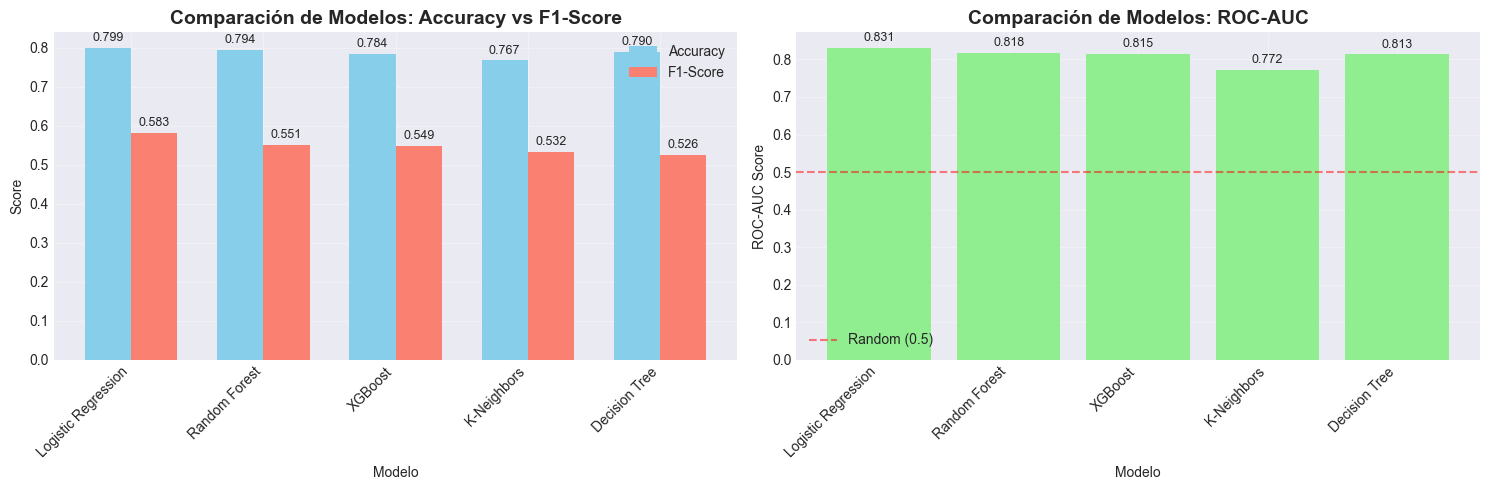

In [5]:
# Modelos base
print("=" * 60)
print("ENTRENANDO MODELOS BASE")
print("=" * 60)

# Lista de modelos
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'K-Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results = []

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"\n🔧 Entrenando {name}...")
    
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predecir en validation
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métricas
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba) if y_pred_proba is not None else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"   ✅ Accuracy: {accuracy:.4f}")
    print(f"   ✅ F1-Score: {f1:.4f}")
    print(f"   ✅ ROC-AUC:  {roc_auc:.4f}" if roc_auc is not None else "   ✅ ROC-AUC:  N/A")

# Crear DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "=" * 60)
print("RESULTADOS COMPARATIVOS (ordenados por F1-Score)")
print("=" * 60)
display(results_df.style.background_gradient(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], cmap='YlOrRd'))

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Accuracy y F1-Score
ax1 = axes[0]
x = np.arange(len(results_df))
width = 0.35

bars1 = ax1.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = ax1.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='salmon')

ax1.set_xlabel('Modelo')
ax1.set_ylabel('Score')
ax1.set_title('Comparación de Modelos: Accuracy vs F1-Score', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Agregar valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: ROC-AUC
ax2 = axes[1]
bars3 = ax2.bar(results_df['Model'], results_df['ROC-AUC'], color='lightgreen')
ax2.set_xlabel('Modelo')
ax2.set_ylabel('ROC-AUC Score')
ax2.set_title('Comparación de Modelos: ROC-AUC', fontsize=14, fontweight='bold')
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Agregar valores
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Feature Importance del mejor modelo
print("=" * 60)
print("ANÁLISIS DE FEATURE IMPORTANCE")
print("=" * 60)

# Identificar el mejor modelo
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"📊 Mejor modelo: {best_model_name}")

# Si el modelo tiene feature_importances_
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Crear DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)
    
    print(f"\n🔝 Top 15 características más importantes:")
    display(importance_df)
    
    # Gráfico
    plt.figure(figsize=(12, 8))
    bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
    plt.xlabel('Importancia', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Agregar valores
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 INSIGHTS:")
    print("-" * 40)
    print(f"1. Característica más importante: {importance_df.iloc[0]['Feature']}")
    print(f"2. Top 3: {list(importance_df['Feature'].head(3))}")
    print(f"3. Features creadas en el ranking:")
    for idx, row in importance_df.iterrows():
        if any(keyword in row['Feature'] for keyword in ['num_services', 'tenure', 'charge', 'senior']):
            print(f"   • {row['Feature']}: posición {idx+1}")
    
elif hasattr(best_model, 'coef_'):  # Para regresión logística
    print("\n📈 Coeficientes de Regresión Logística:")
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', ascending=False)
    
    # Top positivos y negativos
    print("\n🔝 Top 10 coeficientes POSITIVOS (aumentan churn):")
    display(coef_df.head(10))
    
    print("\n🔻 Top 10 coeficientes NEGATIVOS (disminuyen churn):")
    display(coef_df.tail(10))

ANÁLISIS DE FEATURE IMPORTANCE
📊 Mejor modelo: Logistic Regression

📈 Coeficientes de Regresión Logística:

🔝 Top 10 coeficientes POSITIVOS (aumentan churn):


,Feature,Coefficient
21,InternetService_Fiber optic,0.896382
15,tenure_group,0.554874
13,TotalCharges,0.474397
11,PaperlessBilling,0.391321
26,PaymentMethod_Electronic check,0.357130
20,MultipleLines_Yes,0.240333
10,StreamingMovies,0.200094
9,StreamingTV,0.181772
14,num_services,0.124945
17,is_senior,0.075172



🔻 Top 10 coeficientes NEGATIVOS (disminuyen churn):


,Feature,Coefficient
12,MonthlyCharges,-0.094914
6,OnlineBackup,-0.203267
2,Dependents,-0.217786
5,OnlineSecurity,-0.389835
8,TechSupport,-0.443223
4,PhoneService,-0.460640
23,Contract_One year,-0.755649
22,InternetService_No,-0.896377
24,Contract_Two year,-1.387448
3,tenure,-1.780059


In [ ]:
# Optimización del mejor modelo
print("=" * 60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("=" * 60)

# Usaremos Random Forest como ejemplo (generalmente funciona bien)
print("🔧 Optimizando Random Forest...")

# Definir parámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Crear modelo base
rf = RandomForestClassifier(random_state=42)

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='f1',  # Optimizar para F1-Score
    n_jobs=-1,  # Usar todos los cores
    verbose=1
)

print("⏳ Ejecutando GridSearchCV (puede tomar unos minutos)...")
grid_search.fit(X_train, y_train)

print("\n✅ Optimización completada")
print(f"🎯 Mejores parámetros: {grid_search.best_params_}")
print(f"🎯 Mejor score (F1): {grid_search.best_score_:.4f}")

# Evaluar en validation set
best_rf = grid_search.best_estimator_
y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

print("\n📊 Rendimiento en Validation Set:")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}")

# Guardar el mejor modelo
os.makedirs('../models', exist_ok=True)
joblib.dump(best_rf, '../models/best_rf_model.joblib')
print("\n💾 Modelo guardado en: ../models/best_rf_model.joblib")

OPTIMIZACIÓN DE HIPERPARÁMETROS
🔧 Optimizando Random Forest...
⏳ Ejecutando GridSearchCV (puede tomar unos minutos)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


EVALUACIÓN FINAL EN TEST SET
📊 MÉTRICAS EN TEST SET:
----------------------------------------
Accuracy:  0.7975
Precision: 0.6528
Recall:    0.5036
F1-Score:  0.5685
ROC-AUC:   0.8455

🎯 MATRIZ DE CONFUSIÓN:


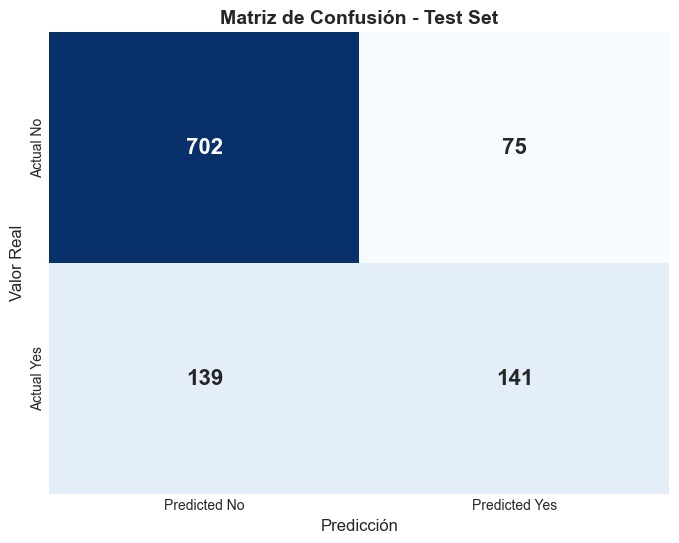


📋 REPORTE DE CLASIFICACIÓN:
----------------------------------------
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87       777
       Churn       0.65      0.50      0.57       280

    accuracy                           0.80      1057
   macro avg       0.74      0.70      0.72      1057
weighted avg       0.79      0.80      0.79      1057



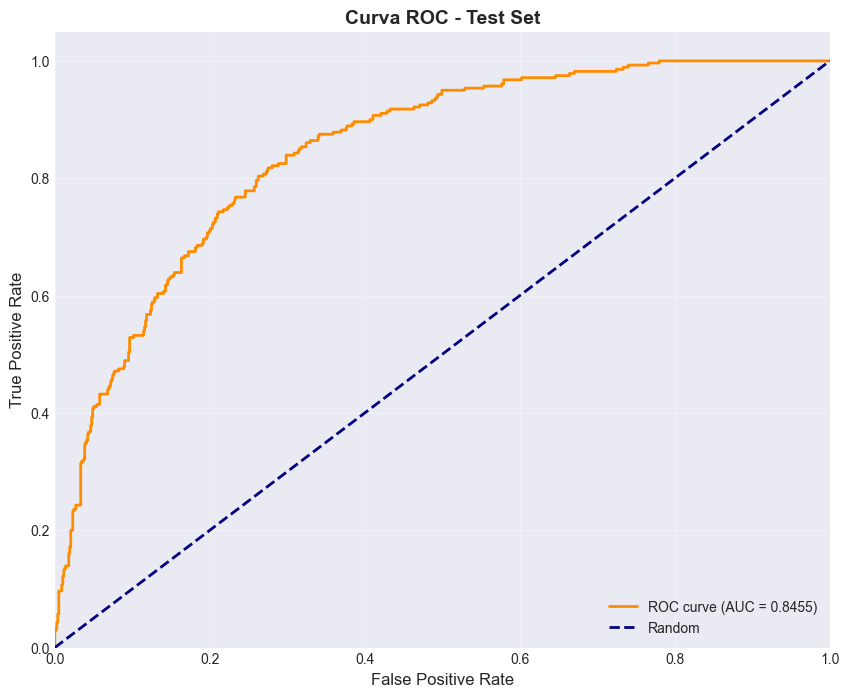

In [10]:
# Evaluación final
print("=" * 60)
print("EVALUACIÓN FINAL EN TEST SET")
print("=" * 60)

# Cargar el mejor modelo
best_model = joblib.load('./models/best_rf_model.joblib')

# Predecir en test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("📊 MÉTRICAS EN TEST SET:")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

# Matriz de confusión
print("\n🎯 MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(cm, 
                     index=['Actual No', 'Actual Yes'], 
                     columns=['Predicted No', 'Predicted Yes'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
plt.title('Matriz de Confusión - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.show()

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print("-" * 40)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Curva ROC - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()